In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
#Loading the dataset
diabetes_data = pd.read_csv('diabetes.csv')

#Print the first 5 rows of the dataframe.
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
## observing the shape of the data
diabetes_data.shape

(768, 9)

In [4]:
X = diabetes_data.drop("Outcome",axis = 1)
y = diabetes_data.Outcome

In [5]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [6]:
#importing train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1/3,random_state=42, stratify=y)

# Decision Tree

In [7]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',random_state=0)
dt.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(dt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(dt.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.703


The accuracy on the training set is 100%, while the test set accuracy is much worse. This is an indicative that the tree is overfitting and not generalizing well to new data. Therefore, we need to apply pre-pruning to the tree.

We set max_depth=3, limiting the depth of the tree decreases overfitting. This leads to a lower accuracy on the training set, but an improvement on the test set.

In [8]:
dt = DecisionTreeClassifier(criterion='entropy',max_depth=3, random_state=0)
dt.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(dt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(dt.score(X_test, y_test)))

Accuracy on training set: 0.793
Accuracy on test set: 0.730


In [9]:
y_pred = dt.predict(X_test)


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[145  22]
 [ 47  42]]
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       167
           1       0.66      0.47      0.55        89

    accuracy                           0.73       256
   macro avg       0.71      0.67      0.68       256
weighted avg       0.72      0.73      0.72       256



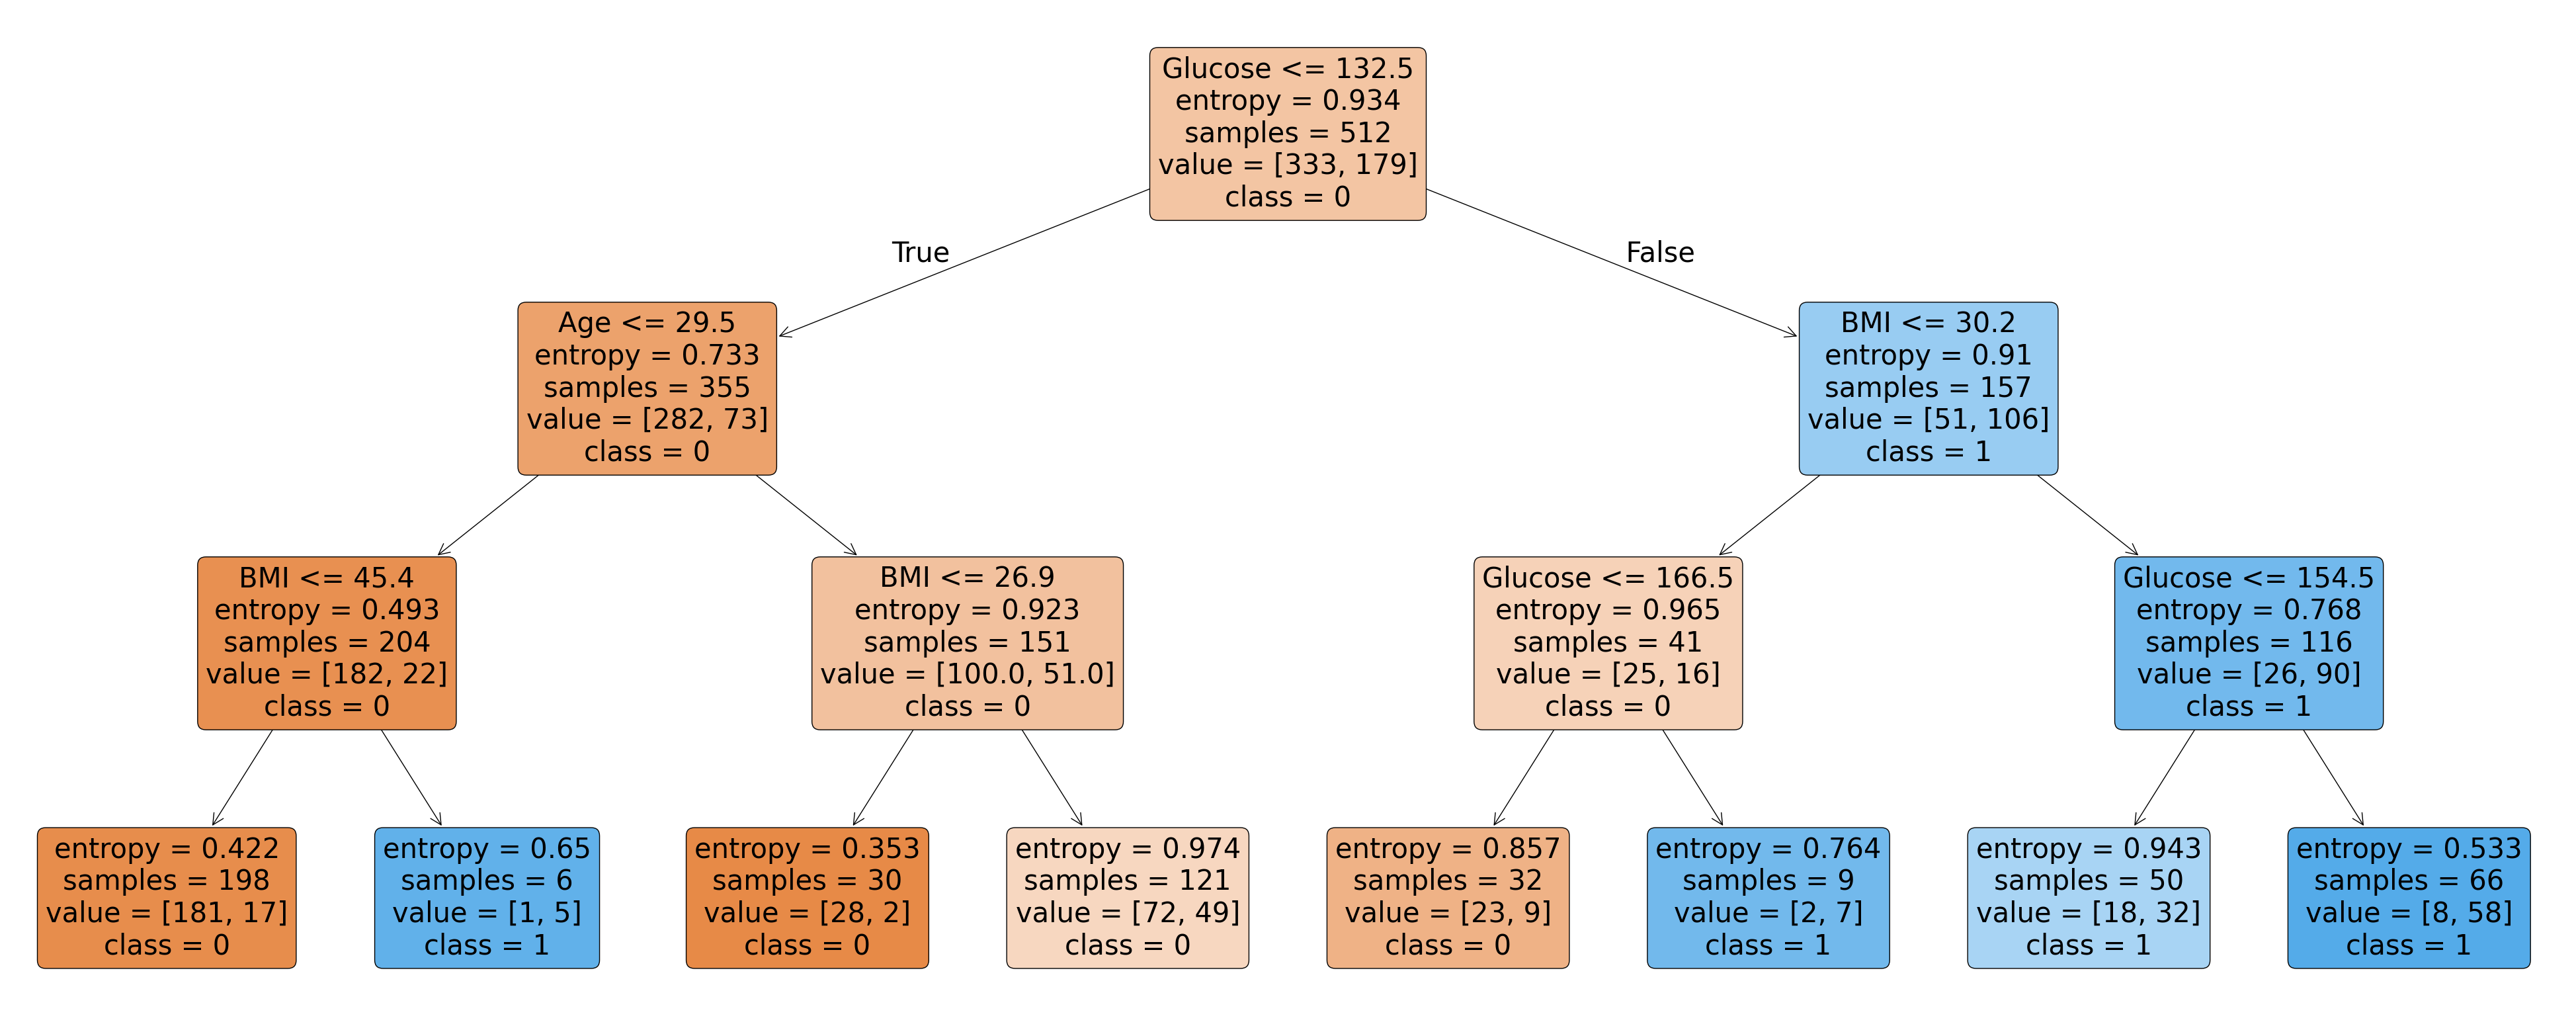

In [11]:
from sklearn import tree
import pydotplus
#import matplotlib.pyplot as plt
plt.figure(figsize=[50,20])

feature_names=X.columns.tolist()
tree.plot_tree(dt,filled=True,fontsize=30,rounded=True,feature_names=feature_names,class_names=['0','1'])
plt.show()

In [ ]:
#Plot ROC chart for DT.Write your code below.

In [ ]:
#Adjust the decision tree parameters to improve the performance.Write your code below.



In [ ]:
#find out the feature importance from the decision tree built above. Write your code below.


# NN

In [12]:

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000,verbose=2)
mlp.fit(X_train, y_train)

Iteration 1, loss = 0.68544381
Iteration 2, loss = 0.67929712
Iteration 3, loss = 0.67397232
Iteration 4, loss = 0.66882537
Iteration 5, loss = 0.66407190
Iteration 6, loss = 0.65944207
Iteration 7, loss = 0.65528274
Iteration 8, loss = 0.65142414
Iteration 9, loss = 0.64745204
Iteration 10, loss = 0.64392040
Iteration 11, loss = 0.64032436
Iteration 12, loss = 0.63694249
Iteration 13, loss = 0.63366813
Iteration 14, loss = 0.63036048
Iteration 15, loss = 0.62723174
Iteration 16, loss = 0.62401472
Iteration 17, loss = 0.62110265
Iteration 18, loss = 0.61780394
Iteration 19, loss = 0.61475339
Iteration 20, loss = 0.61154894
Iteration 21, loss = 0.60845857
Iteration 22, loss = 0.60541069
Iteration 23, loss = 0.60225722
Iteration 24, loss = 0.59912219
Iteration 25, loss = 0.59608837
Iteration 26, loss = 0.59292832
Iteration 27, loss = 0.58969992
Iteration 28, loss = 0.58629608
Iteration 29, loss = 0.58306601
Iteration 30, loss = 0.57946064
Iteration 31, loss = 0.57609265
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, verbose=2)

In [14]:
predictions = mlp.predict(X_test)


print("Accuracy", metrics.accuracy_score(y_test, predictions))
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

Accuracy 0.71484375
[[129  38]
 [ 35  54]]
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       167
           1       0.59      0.61      0.60        89

    accuracy                           0.71       256
   macro avg       0.69      0.69      0.69       256
weighted avg       0.72      0.71      0.72       256



In [15]:
print("Accuracy on training set: {:.3f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp.score(X_test, y_test)))

Accuracy on training set: 0.861
Accuracy on test set: 0.715


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
import pandas as pd
import numpy as np

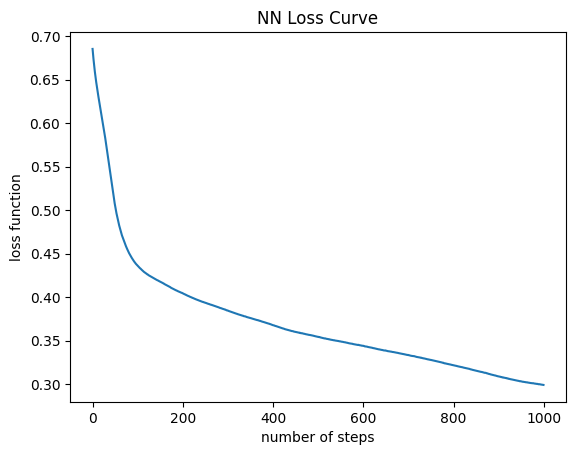

In [16]:
plt.plot(mlp.loss_curve_)
plt.title("NN Loss Curve")
plt.xlabel("number of steps")
plt.ylabel("loss function")
plt.show()

In [ ]:
#check out weights

In [17]:
(mlp.intercepts_[0]).shape

(10,)

In [18]:
(mlp.coefs_[0]).shape

(8, 10)

In [20]:
mlp.intercepts_[0]

array([ 0.45079054,  0.30052141, -1.22757998,  0.01087   ,  0.63989958,
        0.12000113, -0.52106044,  0.80612308,  0.60948684, -0.02596015])

In [21]:
mlp.coefs_[0]

array([[-3.75380729e-01,  8.53018042e-01, -5.08042603e-01,
        -7.46274894e-01, -3.66126044e-01,  1.96921152e-01,
        -1.10631146e+00,  7.30336843e-02,  6.67109581e-01,
         7.75158816e-04],
       [ 1.02213440e-01,  6.79576022e-01, -5.17935795e-01,
         5.87860419e-01, -1.66363840e-02, -2.31229777e-01,
        -7.02929942e-01,  1.16011607e-01,  7.39366646e-02,
         6.06624422e-01],
       [ 8.43348520e-01, -2.63086313e-01,  2.39722866e-01,
        -4.28183192e-01,  1.01986586e-01, -3.92245475e-01,
         3.28384423e-01, -3.79818531e-01,  4.98299854e-01,
        -2.08072167e-01],
       [-2.43097223e-01,  3.20646750e-01, -1.50213787e-01,
         1.70823630e-01,  6.75368131e-01,  5.91728669e-01,
        -1.10845116e+00, -9.43655961e-01,  4.91295704e-01,
        -3.45851913e-01],
       [ 6.39558864e-01, -3.99910517e-01,  4.43161919e-01,
         3.12891720e-01,  2.48675020e-02, -9.81776104e-02,
        -1.62028149e-01,  1.48616765e-01,  4.87060959e-01,
        -2.

In [ ]:

#Adjust the number of hidde Layer/ hidden node to improve the NN performance. Write your code below.


# SVM

In [22]:
from sklearn.svm import SVC

gamma1, gamma2 = 0.1, 1
C1, C2 = 1, 10
hyperparams = (gamma1, C1), (gamma1, C2), (gamma2, C1), (gamma2, C2)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

svm_clfs = []
for gamma, C in hyperparams:
    svm_clf=SVC(kernel="rbf",gamma=gamma, C=C)
    svm_clf.fit(X_train,y_train)
    svm_clfs.append(svm_clf)

from sklearn.metrics import classification_report, confusion_matrix
for i, svm_clf in enumerate(svm_clfs):
    predictions = svm_clf.predict(X_test)
    gamma, C = hyperparams[i]
    print("r=", gamma, "C=", C)
    print("Accuracy=", metrics.accuracy_score(y_test, predictions))
    print(confusion_matrix(y_test,predictions))
    print(classification_report(y_test,predictions))


r= 0.1 C= 1
Accuracy= 0.75390625
[[143  24]
 [ 39  50]]
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       167
           1       0.68      0.56      0.61        89

    accuracy                           0.75       256
   macro avg       0.73      0.71      0.72       256
weighted avg       0.75      0.75      0.75       256

r= 0.1 C= 10
Accuracy= 0.7109375
[[134  33]
 [ 41  48]]
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       167
           1       0.59      0.54      0.56        89

    accuracy                           0.71       256
   macro avg       0.68      0.67      0.67       256
weighted avg       0.71      0.71      0.71       256

r= 1 C= 1
Accuracy= 0.70703125
[[150  17]
 [ 58  31]]
              precision    recall  f1-score   support

           0       0.72      0.90      0.80       167
           1       0.65      0.35      0.45        89

    accuracy    

# deployment

In [23]:
import pickle
# save the model to disk
filename = 'finalized_model.sav'
pickle.dump(mlp, open(filename, 'wb'))

# some time later...

# load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))
#result = loaded_model.score(X_test, y_test)
#print(result)

pred = loaded_model.predict(X_test)
print(pred)


[0 0 1 0 1 1 1 1 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0
 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1
 0 1 0 0 1 0 0 0 0 1 1 1 1 1 1 0 0 0 1 0 1 1 0 0 1 0 0 1 0 1 1 0 0 0 0 0 1
 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0
 0 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 1
 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1 0 1 1
 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0]


# Additional code for your reference:
https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html